# 02 — Modeling: Uber & Lyft Price Prediction

Models trained:
1. Linear Regression (baseline)
2. Polynomial Regression (degree=2)
3. Ridge Regression with CV (RidgeCV)
4. **LightGBM** (primary)
5. **XGBoost** (comparison)

All gradient-boosted models use stratified splits on `weather_group + cab_type + time_period`.

Artifacts saved to `../model/` for the Streamlit app.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightgbm as lgb
import xgboost as xgb
import shap

MODEL_DIR = Path('../model')
MODEL_DIR.mkdir(exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load & Engineer Features

In [2]:
df_raw = pd.read_csv('../data/rideshare_kaggle.csv')
df = df_raw.dropna(subset=['price']).copy()
print(f'Rows after dropna: {len(df):,}')

# ── Time features
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour']       = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek   # 0=Mon
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

def time_period(h):
    if   h in range(6, 10):  return 'morning_commute'
    elif h in range(10, 16): return 'midday'
    elif h in range(16, 20): return 'evening_commute'
    elif h in range(20, 24): return 'nightlife'
    else:                    return 'late_night'

df['time_period'] = df['hour'].apply(time_period)

# ── Price features
df['price_per_mile'] = df['price'] / df['distance'].replace(0, np.nan)
df['route'] = df['source'] + ' → ' + df['destination']

# ── Weather group
def weather_group(row):
    if row.get('short_summary', '') in ['Rain', 'Drizzle', 'Flurries', 'Snow', 'Sleet']:
        return 'precipitation'
    if row.get('windSpeed', 0) > 15:
        return 'windy'
    if row.get('temperature', 50) < 30:
        return 'cold'
    return 'clear'

df['weather_group'] = df.apply(weather_group, axis=1)

print('Feature engineering done.')
df[['price','distance','hour','is_weekend','temperature','precipProbability','windSpeed',
    'name','cab_type','source','destination','time_period','weather_group']].head(3)

Rows after dropna: 637,976
Feature engineering done.


,price,distance,hour,is_weekend,temperature,precipProbability,windSpeed,name,cab_type,source,destination,time_period,weather_group
0,5.0,0.44,9,1,42.34,0.0,8.66,Shared,Lyft,Haymarket Square,North Station,morning_commute,clear
1,11.0,0.44,2,0,43.58,1.0,11.98,Lux,Lyft,Haymarket Square,North Station,late_night,clear
2,7.0,0.44,1,0,38.33,0.0,7.33,Lyft,Lyft,Haymarket Square,North Station,late_night,clear


## 2. Feature Sets

In [3]:
NUM_FEATURES = ['distance', 'surge_multiplier', 'hour', 'is_weekend',
                'temperature', 'precipProbability', 'windSpeed']
CAT_FEATURES = ['name', 'cab_type', 'source', 'destination']
TARGET       = 'price'

X = df[NUM_FEATURES + CAT_FEATURES].copy()
y = df[TARGET].copy()

print(f'X shape: {X.shape}, y shape: {y.shape}')

X shape: (637976, 11), y shape: (637976,)


## 3. Stratified Train/Test Split

In [4]:
# Build stratification key
strat_key = df['weather_group'] + '__' + df['cab_type'] + '__' + df['time_period']

# Drop rare combinations (< 20 samples) to avoid stratification errors
key_counts = strat_key.value_counts()
valid_mask = strat_key.isin(key_counts[key_counts >= 20].index)
X_valid = X[valid_mask]
y_valid = y[valid_mask]
strat_valid = strat_key[valid_mask]

print(f'Samples after dropping rare strat keys: {len(X_valid):,} (dropped {(~valid_mask).sum():,})')

try:
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_valid, y_valid, test_size=0.15, random_state=42, stratify=strat_valid
    )
except ValueError:
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_valid, y_valid, test_size=0.15, random_state=42
    )

print(f'Train: {len(X_train_full):,}  |  Test: {len(X_test):,}')

Samples after dropping rare strat keys: 637,976 (dropped 0)
Train: 542,279  |  Test: 95,697


## 4. Preprocessor

In [5]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES),
], remainder='drop')

X_train_proc = preprocessor.fit_transform(X_train_full)
X_test_proc  = preprocessor.transform(X_test)

# Feature names after encoding
cat_names   = preprocessor.named_transformers_['cat'].get_feature_names_out(CAT_FEATURES).tolist()
feature_names = NUM_FEATURES + cat_names

print(f'Processed feature count: {X_train_proc.shape[1]}')
print(f'First few features: {feature_names[:10]}')

Processed feature count: 45
First few features: ['distance', 'surge_multiplier', 'hour', 'is_weekend', 'temperature', 'precipProbability', 'windSpeed', 'name_Black', 'name_Black SUV', 'name_Lux']


## 5. Baseline Models

In [6]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{name:30s}  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}')
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

results = {}

# ── Linear Regression
lr = LinearRegression()
lr.fit(X_train_proc, y_train_full)
results['Linear'] = {'test': evaluate('Linear Regression', y_test, lr.predict(X_test_proc))}

# ── Ridge CV
ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge.fit(X_train_proc, y_train_full)
results['Ridge'] = {'test': evaluate(f'Ridge (α={ridge.alpha_:.2f})', y_test, ridge.predict(X_test_proc))}

print('\nBaseline models done.')

Linear Regression               MAE=1.742  RMSE=2.477  R²=0.9287
Ridge (α=0.10)                  MAE=1.742  RMSE=2.477  R²=0.9287

Baseline models done.


In [7]:
# ── Polynomial Regression (degree=2, on numeric features only to keep dimensions manageable)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_num = X_train_full[NUM_FEATURES].copy()
X_test_num  = X_test[NUM_FEATURES].copy()

scaler_poly = StandardScaler()
X_train_num_sc = scaler_poly.fit_transform(X_train_num)
X_test_num_sc  = scaler_poly.transform(X_test_num)

X_train_poly = poly.fit_transform(X_train_num_sc)
X_test_poly  = poly.transform(X_test_num_sc)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train_full)
results['Polynomial'] = {'test': evaluate('Polynomial (degree=2)', y_test, lr_poly.predict(X_test_poly))}

print('Polynomial model done.')

Polynomial (degree=2)           MAE=6.928  RMSE=8.443  R²=0.1721
Polynomial model done.


## 6. LightGBM with Early Stopping

In [8]:
# Carve a validation set from train for early stopping (stratified)
strat_train = strat_key[X_train_full.index]
key_counts_train = strat_train.value_counts()
valid_train_mask = strat_train.isin(key_counts_train[key_counts_train >= 2].index)

X_tr_sub = X_train_full[valid_train_mask]
y_tr_sub = y_train_full[valid_train_mask]
strat_tr_sub = strat_train[valid_train_mask]

try:
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tr_sub, y_tr_sub, test_size=0.10, random_state=42, stratify=strat_tr_sub
    )
except ValueError:
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tr_sub, y_tr_sub, test_size=0.10, random_state=42
    )

X_tr_proc  = preprocessor.transform(X_tr)
X_val_proc = preprocessor.transform(X_val)

print(f'LGB train: {len(X_tr):,}  val: {len(X_val):,}')

lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgb_callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100),
]

lgb_model.fit(
    X_tr_proc, y_tr,
    eval_set=[(X_tr_proc, y_tr), (X_val_proc, y_val)],
    eval_metric='mae',
    callbacks=lgb_callbacks,
)

lgb_preds_test = lgb_model.predict(X_test_proc)
results['LightGBM'] = {'test': evaluate('LightGBM', y_test, lgb_preds_test)}
print(f'Best iteration: {lgb_model.best_iteration_}')

LGB train: 488,051  val: 54,228
[100]	training's l1: 1.11922	training's l2: 2.87405	valid_1's l1: 1.11547	valid_1's l2: 2.85729
[200]	training's l1: 1.07822	training's l2: 2.70763	valid_1's l1: 1.07747	valid_1's l2: 2.71576
[300]	training's l1: 1.06725	training's l2: 2.65208	valid_1's l1: 1.07011	valid_1's l2: 2.68679
[400]	training's l1: 1.05905	training's l2: 2.61191	valid_1's l1: 1.06488	valid_1's l2: 2.66716
[500]	training's l1: 1.05195	training's l2: 2.5763	valid_1's l1: 1.06075	valid_1's l2: 2.65082
[600]	training's l1: 1.04582	training's l2: 2.54266	valid_1's l1: 1.05769	valid_1's l2: 2.63724
[700]	training's l1: 1.0406	training's l2: 2.51585	valid_1's l1: 1.05537	valid_1's l2: 2.62863
[800]	training's l1: 1.03461	training's l2: 2.4868	valid_1's l1: 1.05207	valid_1's l2: 2.61641
[900]	training's l1: 1.02965	training's l2: 2.46176	valid_1's l1: 1.04981	valid_1's l2: 2.60687
[1000]	training's l1: 1.02576	training's l2: 2.44025	valid_1's l1: 1.04837	valid_1's l2: 2.59868
[1100]	tra

## 7. XGBoost with Early Stopping

In [9]:
xgb_model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='mae',
    early_stopping_rounds=50,
    verbosity=0,
)

xgb_model.fit(
    X_tr_proc, y_tr,
    eval_set=[(X_tr_proc, y_tr), (X_val_proc, y_val)],
    verbose=100,
)

xgb_preds_test = xgb_model.predict(X_test_proc)
results['XGBoost'] = {'test': evaluate('XGBoost', y_test, xgb_preds_test)}
print(f'Best iteration: {xgb_model.best_iteration}')

[0]	validation_0-mae:7.28330	validation_1-mae:7.26914
[100]	validation_0-mae:1.21064	validation_1-mae:1.20841
[200]	validation_0-mae:1.11495	validation_1-mae:1.11383
[300]	validation_0-mae:1.09274	validation_1-mae:1.09381
[400]	validation_0-mae:1.07990	validation_1-mae:1.08341
[500]	validation_0-mae:1.06989	validation_1-mae:1.07567
[600]	validation_0-mae:1.06282	validation_1-mae:1.07116
[700]	validation_0-mae:1.05751	validation_1-mae:1.06833
[800]	validation_0-mae:1.05263	validation_1-mae:1.06547
[900]	validation_0-mae:1.04793	validation_1-mae:1.06316
[1000]	validation_0-mae:1.04355	validation_1-mae:1.06089
[1100]	validation_0-mae:1.03996	validation_1-mae:1.05938
[1200]	validation_0-mae:1.03668	validation_1-mae:1.05803
[1300]	validation_0-mae:1.03348	validation_1-mae:1.05670
[1400]	validation_0-mae:1.03050	validation_1-mae:1.05563
[1500]	validation_0-mae:1.02743	validation_1-mae:1.05443
[1600]	validation_0-mae:1.02497	validation_1-mae:1.05377
[1700]	validation_0-mae:1.02249	validation_

## 8. Learning Curves

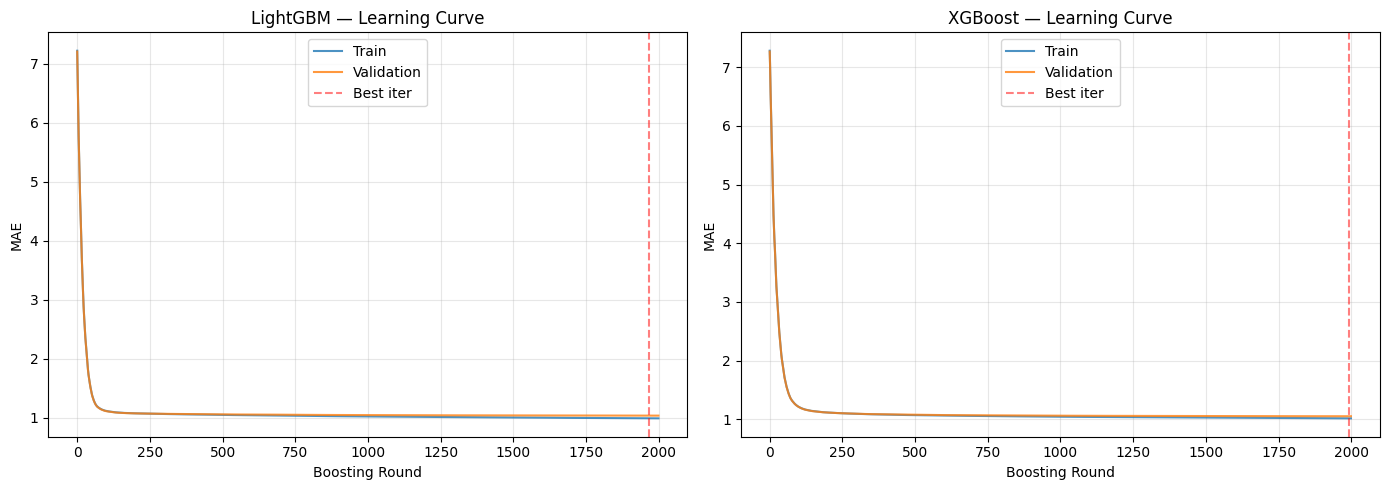

Learning curves saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LightGBM
lgb_hist = lgb_model.evals_result_
lgb_metric = list(lgb_hist['training'].keys())[0]
axes[0].plot(lgb_hist['training'][lgb_metric],   label='Train', alpha=0.8)
axes[0].plot(lgb_hist['valid_1'][lgb_metric],    label='Validation', alpha=0.8)
axes[0].axvline(lgb_model.best_iteration_ - 1, color='red', ls='--', alpha=0.5, label='Best iter')
axes[0].set_title('LightGBM — Learning Curve')
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('MAE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# XGBoost
xgb_hist = xgb_model.evals_result()
axes[1].plot(xgb_hist['validation_0']['mae'], label='Train', alpha=0.8)
axes[1].plot(xgb_hist['validation_1']['mae'], label='Validation', alpha=0.8)
axes[1].axvline(xgb_model.best_iteration, color='red', ls='--', alpha=0.5, label='Best iter')
axes[1].set_title('XGBoost — Learning Curve')
axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../model/learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Learning curves saved.')

## 9. Model Comparison Summary

In [11]:
rows = []
for model_name, res in results.items():
    m = res['test']
    rows.append({'Model': model_name, 'MAE': m['mae'], 'RMSE': m['rmse'], 'R²': m['r2']})

summary = pd.DataFrame(rows).sort_values('MAE')
print(summary.to_string(index=False))

# Performance by cab type on test set
meta_test = X_test.copy()
meta_test['y_true']  = y_test.values
meta_test['lgb_pred'] = lgb_preds_test
meta_test['xgb_pred'] = xgb_preds_test

print('\nLightGBM MAE by cab_type:')
for grp in meta_test['cab_type'].unique():
    mask = meta_test['cab_type'].values == grp
    print(f'  {grp}: {mean_absolute_error(meta_test["y_true"].values[mask], meta_test["lgb_pred"].values[mask]):.3f}')

     Model      MAE     RMSE       R²
  LightGBM 1.046183 1.620853 0.969486
   XGBoost 1.059687 1.636356 0.968900
     Ridge 1.742005 2.477182 0.928727
    Linear 1.742007 2.477182 0.928727
Polynomial 6.927641 8.442795 0.172095

LightGBM MAE by cab_type:
  Lyft: 0.948
  Uber: 1.137


## 10. SHAP Values

In [12]:
# Use a sample of test data for SHAP (full test set can be slow for waterfall)
SHAP_SAMPLE = min(5000, len(X_test))
np.random.seed(42)
shap_idx = np.random.choice(len(X_test), SHAP_SAMPLE, replace=False)

X_shap = X_test_proc[shap_idx]
y_shap = y_test.values[shap_idx]

print(f'Computing SHAP for {SHAP_SAMPLE} samples...')

# LightGBM SHAP
lgb_explainer = shap.TreeExplainer(lgb_model)
lgb_sv = lgb_explainer.shap_values(X_shap)
lgb_base = lgb_explainer.expected_value
lgb_pred_shap = lgb_model.predict(X_shap)
print(f'LGB SHAP done. Base value: {lgb_base:.4f}')

# XGBoost SHAP
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_sv = xgb_explainer.shap_values(X_shap)
xgb_base = xgb_explainer.expected_value
xgb_pred_shap = xgb_model.predict(X_shap)
print(f'XGB SHAP done. Base value: {xgb_base:.4f}')

Computing SHAP for 5000 samples...
LGB SHAP done. Base value: 16.5475
XGB SHAP done. Base value: 16.5484


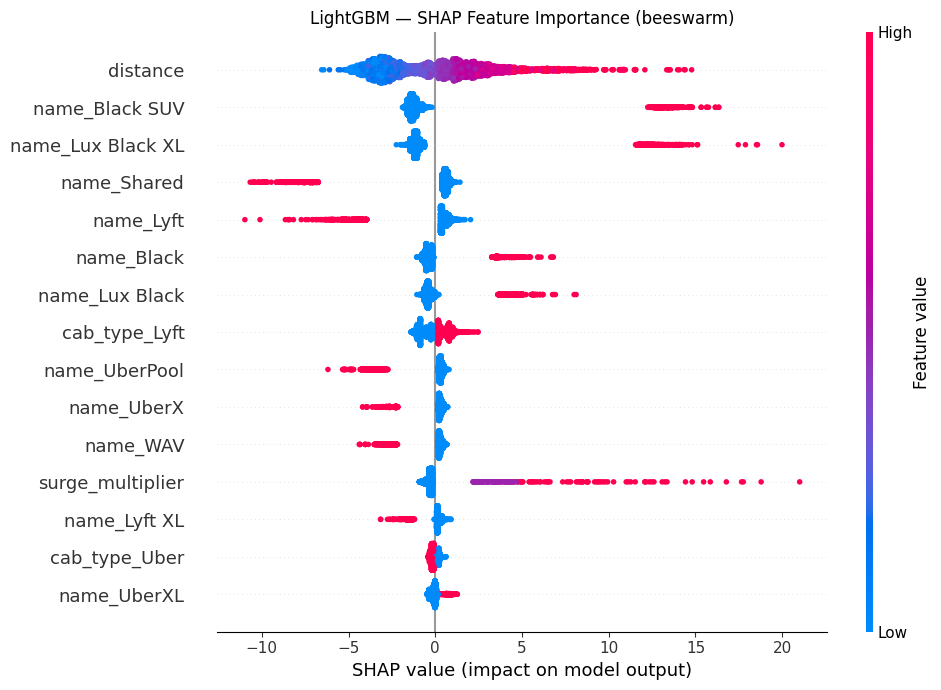

SHAP beeswarm saved.


In [13]:
# Quick SHAP summary plot (matplotlib)
shap.summary_plot(
    lgb_sv, X_shap,
    feature_names=feature_names,
    max_display=15,
    show=False,
    plot_size=(10, 7),
)
plt.title('LightGBM — SHAP Feature Importance (beeswarm)')
plt.tight_layout()
plt.savefig('../model/shap_beeswarm_lgb.png', dpi=120, bbox_inches='tight')
plt.show()
print('SHAP beeswarm saved.')

## 11. Save All Artifacts

In [14]:
# ── sklearn artifacts
joblib.dump(lgb_model,    MODEL_DIR / 'lgb_model.pkl')
joblib.dump(xgb_model,    MODEL_DIR / 'xgb_model.pkl')
joblib.dump(lr,           MODEL_DIR / 'linear_model.pkl')
joblib.dump(ridge,        MODEL_DIR / 'ridge_model.pkl')
joblib.dump(preprocessor, MODEL_DIR / 'preprocessor.pkl')
np.save(MODEL_DIR / 'feature_names.npy', np.array(feature_names, dtype=object))

# ── SHAP artifacts
np.save(MODEL_DIR / 'lgb_shap_vals.npy',  lgb_sv)
np.save(MODEL_DIR / 'xgb_shap_vals.npy',  xgb_sv)
np.save(MODEL_DIR / 'X_shap.npy',         X_shap)
np.save(MODEL_DIR / 'y_shap.npy',         y_shap)
np.save(MODEL_DIR / 'lgb_pred_shap.npy',  lgb_pred_shap)
np.save(MODEL_DIR / 'xgb_pred_shap.npy',  xgb_pred_shap)
np.save(MODEL_DIR / 'lgb_base.npy',       np.array([lgb_base]))
np.save(MODEL_DIR / 'xgb_base.npy',       np.array([xgb_base]))

# ── Metrics JSON (all 4 models, for app comparison page)
metrics_out = {
    'Linear':   results['Linear']['test'],
    'Ridge':    results['Ridge']['test'],
    'LightGBM': results['LightGBM']['test'],
    'XGBoost':  results['XGBoost']['test'],
}
with open(MODEL_DIR / 'model_metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)

print('All artifacts saved to ../model/')
for p in sorted(MODEL_DIR.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size / 1e6:.1f} MB)')

All artifacts saved to ../model/
  .gitkeep  (0.0 MB)
  X_shap.npy  (1.8 MB)
  feature_names.npy  (0.0 MB)
  learning_curves.png  (0.0 MB)
  lgb_base.npy  (0.0 MB)
  lgb_model.pkl  (11.5 MB)
  lgb_pred_shap.npy  (0.0 MB)
  lgb_shap_vals.npy  (1.8 MB)
  linear_model.pkl  (0.0 MB)
  model_metrics.json  (0.0 MB)
  preprocessor.pkl  (0.0 MB)
  ridge_model.pkl  (0.0 MB)
  shap_beeswarm_lgb.png  (0.1 MB)
  xgb_base.npy  (0.0 MB)
  xgb_model.pkl  (9.3 MB)
  xgb_pred_shap.npy  (0.0 MB)
  xgb_shap_vals.npy  (0.9 MB)
  y_shap.npy  (0.0 MB)


## Done

All artifacts are in `../model/`. Launch the app:

```bash
cd app
streamlit run main.py
```